<a href="https://colab.research.google.com/github/rocioivonneperezgonzalez-ship-it/Telecom-X-Parte-2-Predicci-n-de-Cancelaci-n-Churn-/blob/main/Telecom_X_%E2%80%93_Parte_2_Predicci%C3%B3n_de_Cancelaci%C3%B3n_(Churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Parte 2: Predicción de Cancelación (Churn)

📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.


🧠 Objetivos del Desafío


  * Preparar los datos para el modelado (tratamiento, codificación, normalización).

  * Realizar análisis de correlación y selección de variables.

  * Entrenar dos o más modelos de clasificación.

  * Evaluar el rendimiento de los modelos con métricas.

  * Interpretar los resultados, incluyendo la importancia de las variables.

  * Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning

✅ Construcción y evaluación de modelos predictivos

✅ Interpretación de resultados y entrega de insights

✅ Comunicación técnica con enfoque estratégico

# 1. Extracción del Archivo Tratado

Cargar el archivo CSV que contiene los datos tratados anteriormente.
Utilizando el mismo archivo que limpiamos y organizamos en la Parte 1 del desafio, el cuela debe obtener solo las columnsas relevantes, ya con los datos corregidos

In [1]:
import pandas as pd

url = 'https://drive.google.com/uc?id=1kNOO4qdvddUPEOFTu20f4Sa85CjvvyGi'
datos = pd.read_csv(url)

datos.head()


,id,Churn,genero,mayor_de_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,Cuentas_Diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,Yes,Cheque enviado por correo,65.6,593.30,19.776667
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensual,No,Cheque enviado por correo,59.9,542.40,18.080000
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Mensual,Yes,Cheque electrónico,73.9,280.85,9.361667
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Mensual,Yes,Cheque electrónico,98.0,1237.85,41.261667
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Mensual,Yes,Cheque enviado por correo,83.9,267.40,8.913333


# 2. Eliminación de columnas

Eliminemos columnas que no aportan valor al analisis o a los modelos predictivos, como identificadores unicos ( por ejemplo el ID del cliente). Estas columnas nos ayudan en la predicion de la cancelación y puede incluso perjudicar el desempeño de los modelos

In [2]:
datos.columns

Index(['id', 'Churn', 'genero', 'mayor_de_60', 'posee_pareja',
       'posee_dependientes', 'tiempo_contrato', 'servicio_telefono',
       'multiples_lineas', 'tipo_internet', 'seguridad_online',
       'backup_online', 'proteccion_dispositivo', 'soporte_tecnico',
       'streaming_tv', 'streaming_peliculas', 'tipo_contrato',
       'factura_digital', 'metodo_pago', 'valor_mensal', 'total_cobrado',
       'Cuentas_Diarias'],
      dtype='object')

In [3]:
datos = datos.drop(columns=['id'])

In [4]:
datos.columns

Index(['Churn', 'genero', 'mayor_de_60', 'posee_pareja', 'posee_dependientes',
       'tiempo_contrato', 'servicio_telefono', 'multiples_lineas',
       'tipo_internet', 'seguridad_online', 'backup_online',
       'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv',
       'streaming_peliculas', 'tipo_contrato', 'factura_digital',
       'metodo_pago', 'valor_mensal', 'total_cobrado', 'Cuentas_Diarias'],
      dtype='object')

# 3. Enconding

Transformemos las variables categoricas a formato numerico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un metodo de codificación adecuado, como **[one-hot-enconding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)**


***Sugerencia*** Puedes utilizar los metodos get_dummies o one_hot_enconding

Identifiquemos que columnas son numericas

In [5]:
# Separar variable objetivo
y = datos['Churn']

# Separar variables predictoras
X = datos.drop('Churn', axis=1)


In [6]:
X

,genero,mayor_de_60,posee_pareja,posee_dependientes,tiempo_contrato,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,valor_mensal,total_cobrado,Cuentas_Diarias
0,Femenino,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Anual,Yes,Cheque enviado por correo,65.60,593.30,19.776667
1,Masculino,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mensual,No,Cheque enviado por correo,59.90,542.40,18.080000
2,Masculino,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Mensual,Yes,Cheque electrónico,73.90,280.85,9.361667
3,Masculino,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Mensual,Yes,Cheque electrónico,98.00,1237.85,41.261667
4,Femenino,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Mensual,Yes,Cheque enviado por correo,83.90,267.40,8.913333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Femenino,0,0,0,13,1,0,DSL,1,0,0,1,0,0,Anual,No,Cheque enviado por correo,55.15,742.90,24.763333
7039,Masculino,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Mensual,Yes,Cheque electrónico,85.10,1873.70,62.456667
7040,Masculino,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Mensual,Yes,Cheque enviado por correo,50.30,92.75,3.091667
7041,Masculino,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Bienal,No,Cheque enviado por correo,67.85,4627.65,154.255000


In [7]:
type (X)

pandas.core.frame.DataFrame

In [10]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: Churn
Non-Null Count  Dtype
--------------  -----
7043 non-null   int64
dtypes: int64(1)
memory usage: 55.2 KB


## Transformando las varibles explicativas

In [11]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

columnas = X.select_dtypes(include='object').columns

one_hot = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), columnas),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [12]:
X = one_hot.fit_transform(X)

In [13]:
one_hot.get_feature_names_out()

array(['onehotencoder__genero_Masculino',
       'onehotencoder__multiples_lineas_0',
       'onehotencoder__multiples_lineas_1',
       'onehotencoder__multiples_lineas_Sin servicio de teléfono',
       'onehotencoder__tipo_internet_0',
       'onehotencoder__tipo_internet_DSL',
       'onehotencoder__tipo_internet_Fiber optic',
       'onehotencoder__seguridad_online_0',
       'onehotencoder__seguridad_online_1',
       'onehotencoder__seguridad_online_Sin servicio de internet',
       'onehotencoder__backup_online_0', 'onehotencoder__backup_online_1',
       'onehotencoder__backup_online_Sin servicio de internet',
       'onehotencoder__proteccion_dispositivo_0',
       'onehotencoder__proteccion_dispositivo_1',
       'onehotencoder__proteccion_dispositivo_Sin servicio de internet',
       'onehotencoder__soporte_tecnico_0',
       'onehotencoder__soporte_tecnico_1',
       'onehotencoder__soporte_tecnico_Sin servicio de internet',
       'onehotencoder__streaming_tv_0', 'onehoten

In [14]:
pd.DataFrame(X, columns=one_hot.get_feature_names_out())

,onehotencoder__genero_Masculino,onehotencoder__multiples_lineas_0,onehotencoder__multiples_lineas_1,onehotencoder__multiples_lineas_Sin servicio de teléfono,onehotencoder__tipo_internet_0,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__seguridad_online_0,onehotencoder__seguridad_online_1,onehotencoder__seguridad_online_Sin servicio de internet,...,onehotencoder__metodo_pago_Tarjeta de crédito (automático),onehotencoder__metodo_pago_Transferencia bancaria (automática),remainder__mayor_de_60,remainder__posee_pareja,remainder__posee_dependientes,remainder__tiempo_contrato,remainder__servicio_telefono,remainder__valor_mensal,remainder__total_cobrado,remainder__Cuentas_Diarias
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,9.0,1.0,65.60,593.30,19.776667
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,9.0,1.0,59.90,542.40,18.080000
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,1.0,73.90,280.85,9.361667
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,13.0,1.0,98.00,1237.85,41.261667
4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,3.0,1.0,83.90,267.40,8.913333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,13.0,1.0,55.15,742.90,24.763333
7039,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,22.0,1.0,85.10,1873.70,62.456667
7040,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,1.0,50.30,92.75,3.091667
7041,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,67.0,1.0,67.85,4627.65,154.255000


## Tranformando la variable respuesta

Como la variable y ya esca codificada como 0 y 1, no es necesartio hacer una ntranformación adicional, por lo tanto nos queda:

In [15]:
y = datos['Churn']

In [16]:
# Verifiquemos que no hay cambios
import numpy as np
np.unique(y)

array([0, 1])

# Verificación de la Proporción de Cancelaación (Churn)

Calcular la proporcion de clientes que cancelaron en relacipon con los que permanecen activos

Evalua si existe un desvalance entre las clases, ya que esto pude impactar en los modelos predictivos y en el analisis de resultados

Sugerencia: usar `values_conts()` [link text](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.value_counts.html) de pandas para obtener esta proporcion



In [17]:
# cALCULANDO LA CANTIDA ABSOLUTA
y.value_counts()

,count
Churn,
0,5174
1,1869


HAY:
* 5174 clientes activos
* 1869 clientes que cancelaron

In [18]:
y.value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


Lo que significa:

* 73.4% permanecen

* 26.6% cancelaron

🎯 Interpretación

Si obtienes algo cercano a 70/30:

✔ Sí existe desbalance
✔ No es extremo, pero es moderado

En problemas de churn es completamente normal.

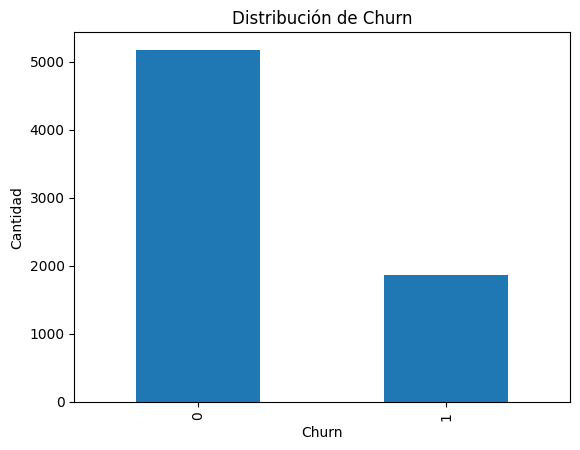

In [19]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad')
plt.show()


### En conlución

La variable objetivo presenta un desbalance moderado, con aproximadamente X% de clientes activos y X% de clientes que cancelaron. Este desbalance puede afectar el desempeño de los modelos predictivos, por lo que se deberán considerar métricas adicionales a la exactitud, como recall, precision y F1-score.